# CTGAN Hyperparameter Optimization with Hepatitis Data

This notebook uses [Optuna](https://optuna.org/) (TPE sampler) to tune the hyperparameters of synthcity's **CTGAN** plugin on the [hepatitis](https://archive.ics.uci.edu/dataset/46/hepatitis) dataset.

**Pipeline**
1. Load pre-processed hepatitis train/test splits from cache.
2. Inspect the CTGAN hyperparameter search space.
3. Run an Optuna study minimizing a combined detection + distributional score.
4. Visualize the study (optimization history, parameter importances, etc.).
5. Train a final CTGAN with the best parameters and compare it against the default.

> **Speed note:** `n_iter` inside each trial is capped at **1000** (vs the default 2 000). 
> Increase `N_TRIALS` and the `n_iter` cap for a deeper search at the cost of runtime.

## 1. Imports & configuration

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import optuna
import torch

from synthcity.benchmark import Benchmarks
from synthcity.plugins import Plugins
from synthcity.plugins.core.dataloader import GenericDataLoader

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Tuning knobs
PLUGIN = "ctgan"
N_TRIALS = 20  # number of Optuna trials
N_ITER_CAP = 1000  # max training iterations per trial (speed vs quality)
N_SAMPLES = 200  # synthetic samples to generate per evaluation
TARGET_COL = "target"
SENSITIVE = ["AGE", "SEX"]

# MPS (Apple Silicon) does not support float64, which synthcity's detection
# metrics require internally. CPU is used for HPO; for small tabular batches
# like hepatitis it is fast enough and avoids dtype errors.
if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"
print(f"Device: {device}")

[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.
Device: cpu


## 2. Load hepatitis data

In [2]:
data_dir = "../data/hepatitis"

train_imputed_df = pd.read_csv(os.path.join(data_dir, "train_imputed.csv"))
test_imputed_df = pd.read_csv(os.path.join(data_dir, "test_imputed.csv"))

print(f"Train shape: {train_imputed_df.shape}")
print(f"Test  shape: {test_imputed_df.shape}")
print("\nTarget distribution (train):")
print(train_imputed_df[TARGET_COL].value_counts())
train_imputed_df.head()

Train shape: (103, 20)
Test  shape: (52, 20)

Target distribution (train):
target
1    82
0    21
Name: count, dtype: int64


,AGE,SEX,STEROID,ANTIVIRALS,FATIGUE,MALAISE,ANOREXIA,LIVER BIG,LIVER FIRM,SPLEEN PALPABLE,SPIDERS,ASCITES,VARICES,BILIRUBIN,ALK PHOSPHATE,SGOT,ALBUMIN,PROTIME,HISTOLOGY,target
0,45,1,0,1,0,0,1,1,1,0,1,1,1,1.0,85,75,3.7,58,0,1
1,54,0,0,1,0,0,1,1,1,0,1,0,1,3.9,120,28,3.5,43,1,0
2,54,0,0,0,1,1,1,0,0,1,1,1,1,1.0,155,225,3.6,67,1,1
3,7,0,1,1,1,1,1,1,0,0,1,1,1,0.7,256,25,4.2,58,1,1
4,51,0,0,1,0,1,0,1,1,0,0,1,1,1.2,97,72,3.7,58,0,0


## 3. Create synthcity DataLoaders

In [3]:
train_loader = GenericDataLoader(
    train_imputed_df,
    target_column=TARGET_COL,
    sensitive_features=SENSITIVE,
    random_state=SEED,
)
test_loader = GenericDataLoader(
    test_imputed_df,
    target_column=TARGET_COL,
    sensitive_features=SENSITIVE,
    random_state=SEED,
)
print(f"Train loader shape: {train_loader.shape}")
print(f"Test loader shape: {test_loader.shape}")

Train loader shape: (103, 20)
Test loader shape: (52, 20)


## 4. Inspect CTGAN hyperparameter space

In [4]:
plugin_cls = type(Plugins().get(PLUGIN))
hp_space = plugin_cls.hyperparameter_space()

print(f"CTGAN hyperparameter space ({len(hp_space)} parameters):\n")
for hp in hp_space:
    if hasattr(hp, "choices"):
        print(f"  {hp.name:40s}  categorical  {hp.choices}")
    elif hasattr(hp, "step"):
        print(f"  {hp.name:40s}  int          [{hp.low}, {hp.high}]  step={hp.step}")
    else:
        print(f"  {hp.name:40s}  float        [{hp.low:.4f}, {hp.high:.4f}]")

[2026-07-06T17:36:09.963424+0300][80638][CRITICAL] load failed: module 'pyarrow' has no attribute 'PyExtensionType'
[2026-07-06T17:36:09.963934+0300][80638][CRITICAL] load failed: module 'synthcity.plugins.generic.plugin_great' has no attribute 'plugin'
[2026-07-06T17:36:09.964090+0300][80638][CRITICAL] module plugin_great load failed
[2026-07-06T17:36:09.970735+0300][80638][CRITICAL] Error importing TabularGoggle: No module named 'dgl'
[2026-07-06T17:36:09.972182+0300][80638][CRITICAL] module disabled: /Users/alp.erkent/Projects/synthdata/submodules/synthcity/src/synthcity/plugins/generic/plugin_goggle.py


CTGAN hyperparameter space (14 parameters):

  generator_n_layers_hidden                 int          [1, 4]  step=1
  generator_n_units_hidden                  int          [50, 150]  step=50
  generator_nonlin                          categorical  ['elu', 'leaky_relu', 'relu', 'tanh']
  n_iter                                    int          [100, 1000]  step=100
  generator_dropout                         float        [0.0000, 0.2000]
  discriminator_n_layers_hidden             int          [1, 4]  step=1
  discriminator_n_units_hidden              int          [50, 150]  step=50
  discriminator_nonlin                      categorical  ['elu', 'leaky_relu', 'relu', 'tanh']
  discriminator_n_iter                      int          [1, 5]  step=1
  discriminator_dropout                     float        [0.0000, 0.2000]
  lr                                        categorical  [0.0001, 0.0002, 0.001]
  weight_decay                              categorical  [0.0001, 0.001]
  batch_size    

## 5. Optuna HPO study

| Metric | Role |
|---|---|
| `prdc` | **Coverage** — recall/coverage components penalize mode collapse; memorizing a cluster leaves other regions uncovered |
| `alpha_precision` | **Realism** — fraction of synthetic samples inside real support; not gameable by memorization alone |
| `wasserstein_dist` | **Joint** distributional distance; harder to satisfy than marginal JS |
| `inv_kl_divergence` | **Distribution-level** fidelity; robust to sample-level copying |
| `nearest_syn_neighbor_distance` | **Direct anti-memorization** — maximize distance from synthetic to nearest training point |
| `xgb` | **TSTR utility** — copying training data won't generalize to the held-out test set |
| `identifiability_score` | **Re-identification risk** — how closely synthetic records map back to real individuals; lower = better privacy |
| `DomiasMIA_prior` | **Membership inference** — how easily an adversary can tell if a record was in training; lower = harder to attack |


The objective combines all eight with direction-aware normalization: orient every metric so *higher = better*, then average → minimize the negation.

In [5]:
METRIC_CONFIG = {
    "stats": [
        "prdc",  # precision + recall + density + coverage
        "alpha_precision",  # fraction of synthetic samples inside real support
        "wasserstein_dist",  # joint distributional distance
        "inv_kl_divergence",  # distribution-level fidelity (inverted KL)
    ],
    "sanity": [
        "nearest_syn_neighbor_distance",  # direct anti-memorization signal
    ],
    "performance": [
        "xgb",  # TSTR: train-on-synthetic, test-on-real utility
    ],
    "privacy": [
        "identifiability_score",  # re-identification risk; lower = better privacy
        "DomiasMIA_prior",  # membership inference attack score; lower = harder to attack
    ],
}


def objective(trial: optuna.Trial) -> float:
    params = plugin_cls.sample_hyperparameters_optuna(trial)
    params["n_iter"] = min(params.get("n_iter", N_ITER_CAP), N_ITER_CAP)
    params["random_state"] = SEED
    params["device"] = device

    trial_id = f"trial_{trial.number}"
    try:
        report = Benchmarks.evaluate(
            [(trial_id, PLUGIN, params)],
            train_loader,
            repeats=1,
            metrics=METRIC_CONFIG,
            task_type="classification",
        )
    except Exception as exc:
        print(f"  Trial {trial.number} failed ({type(exc).__name__}: {exc})")
        raise optuna.TrialPruned()

    df = report[trial_id]

    # Direction-aware composite: orient all metrics so higher = better, then average.
    # Minimizing the negation of this average is equivalent to maximizing quality.
    sign = df["direction"].map({"maximize": 1.0, "minimize": -1.0})
    score = -(df["mean"] * sign).mean()  # negate so optuna minimizes
    print(f"  Trial {trial.number:3d} | score={score:.4f}")
    return score


print("Objective function defined.")

Objective function defined.


In [6]:
sampler = optuna.samplers.TPESampler(seed=SEED)
study = optuna.create_study(
    direction="minimize", sampler=sampler, study_name="ctgan_hpo_hepatitis"
)

print(f"Running {N_TRIALS} trials (n_iter capped at {N_ITER_CAP}) …")
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
pruned = [t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED]
print(f"\nCompleted: {len(completed)}  |  Pruned: {len(pruned)}")

if not completed:
    raise RuntimeError(
        "All trials were pruned — no completed trial to report. "
        "Check the error messages printed above."
    )

print(f"Best trial : #{study.best_trial.number}")
print(f"Best score : {study.best_value:.4f}")
print(f"Best params: {study.best_params}")


Running 20 trials (n_iter capped at 1000) …


  0%|          | 0/20 [00:00<?, ?it/s]

  Trial   0 | score=-0.1670
  Trial   1 | score=-0.2533
  Trial   2 | score=-0.2417
  Trial   3 | score=-0.1744
  Trial   4 | score=-0.2939
  Trial   5 | score=-0.2520
  Trial   6 | score=-0.1900
  Trial   7 | score=-0.2858
  Trial   8 | score=-0.1102
  Trial   9 | score=-0.2485


[2026-07-06T17:36:14.507432+0300][80638][CRITICAL] load failed: module 'synthcity.plugins.generic.plugin_great' has no attribute 'plugin'
[2026-07-06T17:36:14.507823+0300][80638][CRITICAL] load failed: module 'synthcity.plugins.generic.plugin_great' has no attribute 'plugin'
[2026-07-06T17:36:14.508059+0300][80638][CRITICAL] module plugin_great load failed
[2026-07-06T17:36:14.508282+0300][80638][CRITICAL] module disabled: /Users/alp.erkent/Projects/synthdata/submodules/synthcity/src/synthcity/plugins/generic/plugin_goggle.py


  Trial  10 | score=-0.2860


...

  Trial  17 | score=-0.2573


100%|██████████| 500/500 [00:12<00:00, 38.72it/s]
[2026-07-06T17:37:59.608333+0300][80638][CRITICAL] load failed: module 'synthcity.plugins.generic.plugin_great' has no attribute 'plugin'
[2026-07-06T17:37:59.608637+0300][80638][CRITICAL] load failed: module 'synthcity.plugins.generic.plugin_great' has no attribute 'plugin'
[2026-07-06T17:37:59.608834+0300][80638][CRITICAL] module plugin_great load failed
[2026-07-06T17:37:59.609054+0300][80638][CRITICAL] module disabled: /Users/alp.erkent/Projects/synthdata/submodules/synthcity/src/synthcity/plugins/generic/plugin_goggle.py


  Trial  18 | score=-0.2695


 78%|███████▊  | 699/900 [00:21<00:06, 32.85it/s]


  Trial  19 | score=-0.2969

Completed: 20  |  Pruned: 0
Best trial : #16
Best score : -0.3933
Best params: {'generator_n_layers_hidden': 2, 'generator_n_units_hidden': 100, 'generator_nonlin': 'relu', 'n_iter': 900, 'generator_dropout': 0.1500857704189669, 'discriminator_n_layers_hidden': 3, 'discriminator_n_units_hidden': 100, 'discriminator_nonlin': 'relu', 'discriminator_n_iter': 5, 'discriminator_dropout': 0.15814874782226088, 'lr': 0.001, 'weight_decay': 0.001, 'batch_size': 100, 'encoder_max_clusters': 20}


## 6. Study visualisation

In [7]:
from optuna.visualization import (
    plot_optimization_history,
    plot_param_importances,
    plot_slice,
)

plot_optimization_history(study)

In [8]:
plot_param_importances(study)

In [9]:
plot_slice(study)

In [10]:
# Trials summary table
trials_df = study.trials_dataframe(attrs=("number", "value", "params", "state"))
trials_df = trials_df.sort_values("value").reset_index(drop=True)
print("Top 10 trials by score:")
trials_df.head(10)

Top 10 trials by score:


,number,value,params_batch_size,params_discriminator_dropout,params_discriminator_n_iter,params_discriminator_n_layers_hidden,params_discriminator_n_units_hidden,params_discriminator_nonlin,params_encoder_max_clusters,params_generator_dropout,params_generator_n_layers_hidden,params_generator_n_units_hidden,params_generator_nonlin,params_lr,params_n_iter,params_weight_decay,state
0,16,-0.393270,100,0.158149,5,3,100,relu,20,0.150086,2,100,relu,0.0010,900,0.0010,COMPLETE
1,19,-0.296903,200,0.199857,5,4,50,relu,8,0.125684,3,100,relu,0.0010,900,0.0010,COMPLETE
2,4,-0.293867,100,0.174292,4,1,50,relu,6,0.151110,1,100,relu,0.0010,500,0.0010,COMPLETE
3,10,-0.285971,100,0.115474,5,3,100,tanh,20,0.079442,2,100,relu,0.0010,1000,0.0010,COMPLETE
4,7,-0.285812,200,0.018621,2,4,50,leaky_relu,16,0.184939,1,150,leaky_relu,0.0002,200,0.0010,COMPLETE
5,12,-0.271229,100,0.092642,4,2,100,tanh,12,0.080203,1,100,relu,0.0010,1000,0.0010,COMPLETE
6,18,-0.269523,500,0.166598,4,3,100,relu,17,0.158206,2,50,tanh,0.0001,500,0.0001,COMPLETE
7,11,-0.265689,100,0.130536,5,3,100,tanh,20,0.094429,2,100,relu,0.0010,1000,0.0010,COMPLETE
8,14,-0.260919,100,0.082565,5,2,100,tanh,11,0.119206,1,100,relu,0.0010,800,0.0010,COMPLETE
9,17,-0.257282,100,0.164361,3,2,50,relu,13,0.151098,1,100,relu,0.0010,800,0.0010,COMPLETE


## 7. Default vs optimized CTGAN — full benchmark comparison

Evaluate both configurations with a broader metric set so we can see how much HPO actually improves things.

In [11]:
FULL_METRIC_CONFIG = {
    "sanity": [
        "data_mismatch",
        "common_rows_proportion",
        "nearest_syn_neighbor_distance",
        "close_values_probability",
        "distant_values_probability",
    ],
    "stats": [
        "jensenshannon_dist",
        "chi_squared_test",
        "inv_kl_divergence",
        "ks_test",
        "max_mean_discrepancy",
        "wasserstein_dist",
        "prdc",
        "alpha_precision",
    ],
    "performance": [
        "linear_model",
        "mlp",
        "xgb",
        "feat_rank_distance",
    ],
    "detection": [
        "detection_xgb",
        "detection_mlp",
        "detection_gmm",
        "detection_linear",
    ],
    "privacy": [
        "delta-presence",
        "k-anonymization",
        "k-map",
        "distinct l-diversity",
        "identifiability_score",
    ],
}

best_params = dict(study.best_params)
best_params["device"] = device
# Use full n_iter for the final evaluation
best_params_full = {k: v for k, v in best_params.items()}
best_params_full["n_iter"] = 2000

score = Benchmarks.evaluate(
    [
        ("ctgan_default", PLUGIN, {"device": device}),
        ("ctgan_optimized", PLUGIN, best_params_full),
    ],
    train_loader,
    X_test=test_loader,
    synthetic_size=N_SAMPLES,
    task_type="classification",
    repeats=2,
    metrics=FULL_METRIC_CONFIG,
)
Benchmarks.print(score)

[2026-07-06T17:38:22.075183+0300][80638][CRITICAL] load failed: module 'synthcity.plugins.generic.plugin_great' has no attribute 'plugin'
[2026-07-06T17:38:22.075577+0300][80638][CRITICAL] load failed: module 'synthcity.plugins.generic.plugin_great' has no attribute 'plugin'
[2026-07-06T17:38:22.075821+0300][80638][CRITICAL] module plugin_great load failed
[2026-07-06T17:38:22.076045+0300][80638][CRITICAL] module disabled: /Users/alp.erkent/Projects/synthdata/submodules/synthcity/src/synthcity/plugins/generic/plugin_goggle.py
 22%|██▏       | 449/2000 [00:14<00:48, 31.66it/s]
[2026-07-06T17:38:42.517486+0300][80638][CRITICAL] load failed: module 'synthcity.plugins.generic.plugin_great' has no attribute 'plugin'
[2026-07-06T17:38:42.518125+0300][80638][CRITICAL] load failed: module 'synthcity.plugins.generic.plugin_great' has no attribute 'plugin'
[2026-07-06T17:38:42.518427+0300][80638][CRITICAL] module plugin_great load failed
[2026-07-06T17:38:42.518666+0300][80638][CRITICAL] module 


Comparatives


,ctgan_default,ctgan_optimized
sanity.data_mismatch.score,0.0 ± 0.0,0.0 ± 0.0
sanity.common_rows_proportion.score,0.0 ± 0.0,0.0 ± 0.0
sanity.nearest_syn_neighbor_distance.mean,0.095 ± 0.001,0.083 ± 0.004
sanity.close_values_probability.score,0.913 ± 0.01,0.952 ± 0.01
sanity.distant_values_probability.score,0.019 ± 0.0,0.019 ± 0.0
stats.jensenshannon_dist.marginal,0.024 ± 0.002,0.02 ± 0.001
stats.chi_squared_test.marginal,0.603 ± 0.022,0.623 ± 0.015
stats.inv_kl_divergence.marginal,0.809 ± 0.002,0.81 ± 0.024
stats.ks_test.marginal,0.845 ± 0.008,0.882 ± 0.001
stats.max_mean_discrepancy.joint,0.038 ± 0.001,0.038 ± 0.001


In [12]:
Benchmarks.highlight(score)

,ctgan_default,ctgan_optimized
sanity.data_mismatch.score,0.000000,0.000000
sanity.common_rows_proportion.score,0.000000,0.000000
sanity.nearest_syn_neighbor_distance.mean,0.094603,0.083260
sanity.close_values_probability.score,0.913462,0.951923
sanity.distant_values_probability.score,0.019231,0.019231
stats.jensenshannon_dist.marginal,0.024217,0.019803
stats.chi_squared_test.marginal,0.602525,0.623229
stats.inv_kl_divergence.marginal,0.808879,0.809615
stats.ks_test.marginal,0.845192,0.882212
stats.max_mean_discrepancy.joint,0.038462,0.038462


## 8. Linear ranking — utility vs privacy

Mirror the ranking logic from the main notebook: orient all metrics (higher = better), 
min-max scale per metric, then sum into utility and privacy sub-scores.

In [13]:
_SC_CATEGORY_MAP = {
    "sanity": "utility",
    "stats": "utility",
    "performance": "utility",
    "detection": "privacy",
    "privacy": "privacy",
    "attacks": "privacy",
}


def linear_ranking(all_results: dict):
    means_df = pd.DataFrame(
        {model: res["mean"] for model, res in all_results.items()}
    ).T

    first_res = next(iter(all_results.values()))
    directions = first_res["direction"]
    sign = directions.map({"maximize": 1.0, "minimize": -1.0})

    common = means_df.columns.intersection(sign.index)
    oriented = means_df[common].multiply(sign[common], axis=1)
    oriented = oriented.dropna(axis=1, how="all")

    def _minmax(col):
        lo, hi = col.min(), col.max()
        return col.where(col.isna(), 0.5) if hi == lo else (col - lo) / (hi - lo)

    scaled = oriented.apply(_minmax, axis=0)
    metric_cats = pd.Series(
        {
            col: _SC_CATEGORY_MAP.get(col.split(".")[0], "other")
            for col in scaled.columns
        }
    )
    u_cols = metric_cats[metric_cats == "utility"].index.tolist()
    p_cols = metric_cats[metric_cats == "privacy"].index.tolist()

    rank_df = pd.DataFrame(index=scaled.index)
    rank_df["u_rank"] = scaled[u_cols].sum(axis=1)
    rank_df["p_rank"] = scaled[p_cols].sum(axis=1)
    rank_df["rank"] = scaled.sum(axis=1)
    return rank_df.sort_values("rank", ascending=False), scaled


rank_df, scaled_df = linear_ranking(score)
rank_df

,u_rank,p_rank,rank
ctgan_optimized,21.5,8.0,29.5
ctgan_default,10.5,4.0,14.5


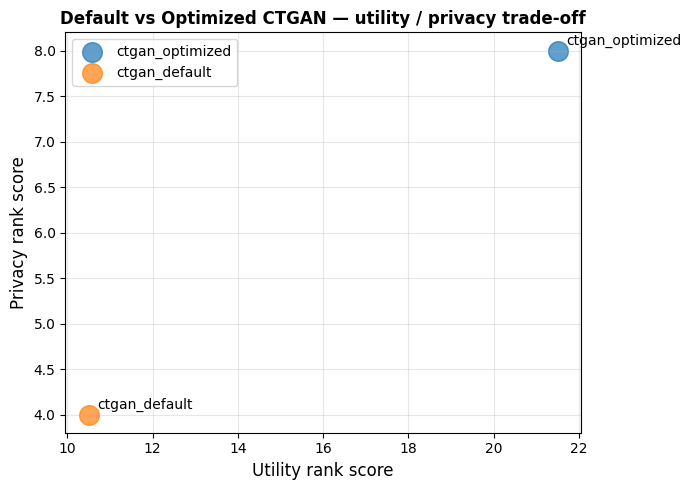

In [16]:
fig, ax = plt.subplots(figsize=(7, 5))
colours = ["tab:blue", "tab:orange"]
for (model, row), colour in zip(rank_df.iterrows(), colours):
    ax.scatter(
        row["u_rank"], row["p_rank"], s=200, alpha=0.7, color=colour, label=model
    )
    ax.annotate(
        model,
        (row["u_rank"], row["p_rank"]),
        xytext=(6, 4),
        textcoords="offset points",
        fontsize=10,
    )
ax.set_xlabel("Utility rank score", fontsize=12)
ax.set_ylabel("Privacy rank score", fontsize=12)
ax.set_title(
    "Default vs Optimized CTGAN — utility / privacy trade-off",
    fontsize=12,
    fontweight="bold",
)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 9. Best hyperparameters — summary

In [15]:
default_plugin = Plugins().get(PLUGIN)
default_params = {hp.name: getattr(default_plugin, hp.name, None) for hp in hp_space}

comparison = pd.DataFrame(
    {
        "default": default_params,
        "optimized": {
            k: study.best_params.get(k, default_params[k]) for k in default_params
        },
    }
)
comparison["changed"] = comparison["default"] != comparison["optimized"]
print(f"Optuna best score : {study.best_value:.4f}")
print(f"Changed parameters: {comparison['changed'].sum()} / {len(comparison)}\n")
comparison.style.apply(
    lambda row: ["background-color: #003d0e" if row["changed"] else "" for _ in row],
    axis=1,
)

[2026-07-06T17:38:59.521213+0300][80638][CRITICAL] load failed: module 'synthcity.plugins.generic.plugin_great' has no attribute 'plugin'
[2026-07-06T17:38:59.521636+0300][80638][CRITICAL] load failed: module 'synthcity.plugins.generic.plugin_great' has no attribute 'plugin'
[2026-07-06T17:38:59.521845+0300][80638][CRITICAL] module plugin_great load failed
[2026-07-06T17:38:59.522173+0300][80638][CRITICAL] module disabled: /Users/alp.erkent/Projects/synthdata/submodules/synthcity/src/synthcity/plugins/generic/plugin_goggle.py


Optuna best score : -0.3933
Changed parameters: 10 / 14



,default,optimized,changed
generator_n_layers_hidden,2,2,False
generator_n_units_hidden,500,100,True
generator_nonlin,relu,relu,False
n_iter,2000,900,True
generator_dropout,0.100000,0.150086,True
discriminator_n_layers_hidden,2,3,True
discriminator_n_units_hidden,500,100,True
discriminator_nonlin,leaky_relu,relu,True
discriminator_n_iter,1,5,True
discriminator_dropout,0.100000,0.158149,True
